In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt
import seaborn as sns
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/real-estate-price-prediction/Real estate.csv


**Menyiapkan Dataset**

In [ ]:
df = pd.read_csv("/kaggle/input/real-estate-price-prediction/Real estate.csv")
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [ ]:
df.shape

(414, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [ ]:
#mengubah representasi tanggal dalam float menjadi integer untuk mengambil bagian
df['X1 transaction date']=df['X1 transaction date'].astype(int)
# df.transaction_date = df.transaction_date.astype()

In [ ]:
df.head() #cek dengan fungsi pandas.DataFrame.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012,5.0,390.56840,5,24.97937,121.54245,43.1


In [ ]:
df.columns

Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')

In [ ]:
# ubah nama kolom menjadi lebih sederhana untuk memudahkan cara akses
new_names = ["No","transaction_date","house_age","dist_to_MRT","conv_store","lat","long","house_price"]
df = df.set_axis(new_names, axis="columns")

In [ ]:
df.set_index("No")

,transaction_date,house_age,dist_to_MRT,conv_store,lat,long,house_price
No,,,,,,,
1,2012,32.0,84.87882,10,24.98298,121.54024,37.9
2,2012,19.5,306.59470,9,24.98034,121.53951,42.2
3,2013,13.3,561.98450,5,24.98746,121.54391,47.3
4,2013,13.3,561.98450,5,24.98746,121.54391,54.8
5,2012,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...
410,2013,13.7,4082.01500,0,24.94155,121.50381,15.4
411,2012,5.6,90.45606,9,24.97433,121.54310,50.0
412,2013,18.8,390.96960,7,24.97923,121.53986,40.6


In [ ]:
#cek jumlah nilai untuk pada setiap kolom
print(df.nunique())

No                  414
transaction_date      2
house_age           236
dist_to_MRT         259
conv_store           11
lat                 234
long                232
house_price         270
dtype: int64


In [ ]:
#cek dan menghapus duplikasi
#df = df.drop_duplicates()
dups = df.duplicated()
print(dups.any())

False


<Axes: >

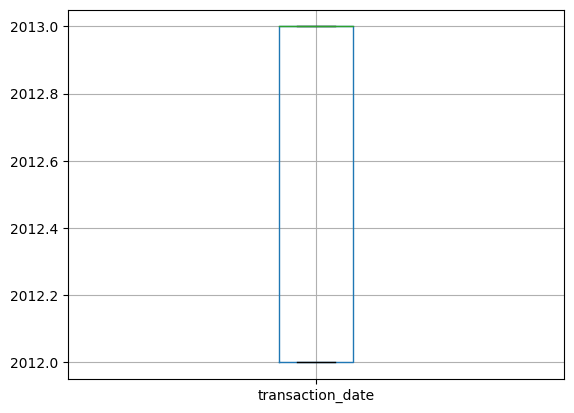

In [ ]:
#proses satu satu setiap kolom
df.boxplot(column = ['transaction_date'])

<Axes: >

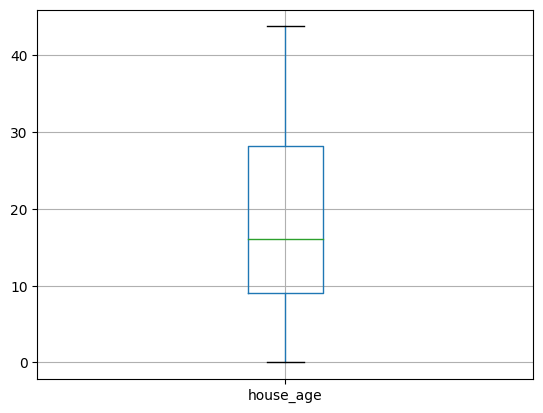

In [ ]:
df.boxplot(column = ['house_age'])

<Axes: >

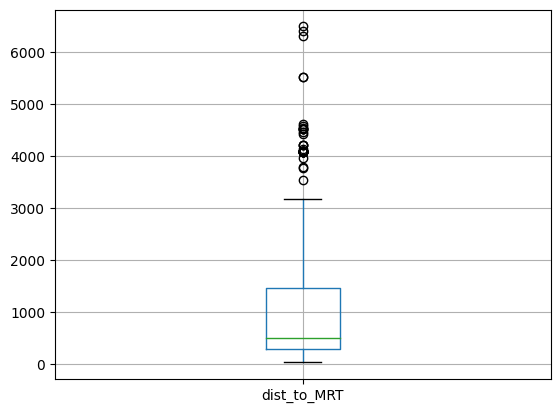

In [ ]:
df.boxplot(column = ['dist_to_MRT'])

<Axes: >

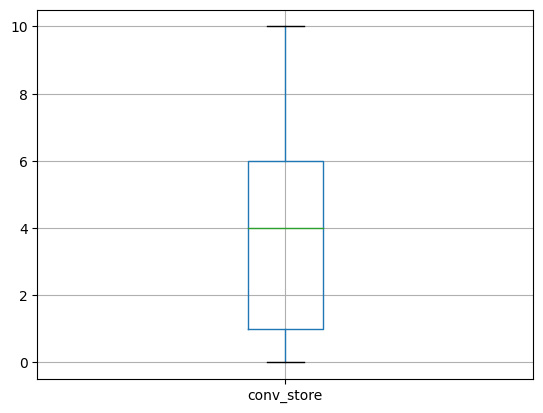

In [ ]:
df.boxplot(column = ['conv_store'])

<Axes: >

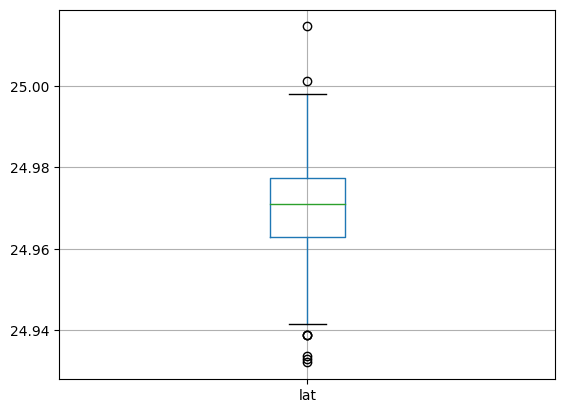

In [ ]:
df.boxplot(column = ['lat'])

<Axes: >

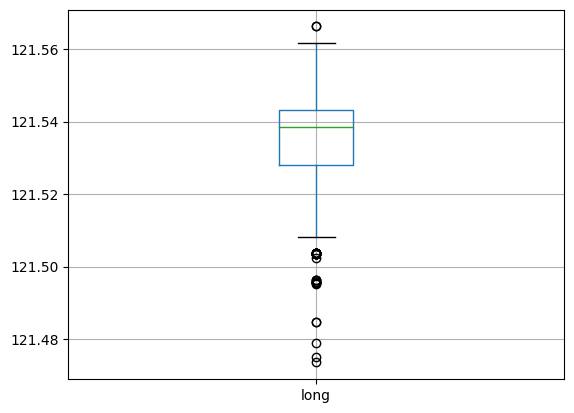

In [ ]:
df.boxplot(column = ['long'])

<Axes: >

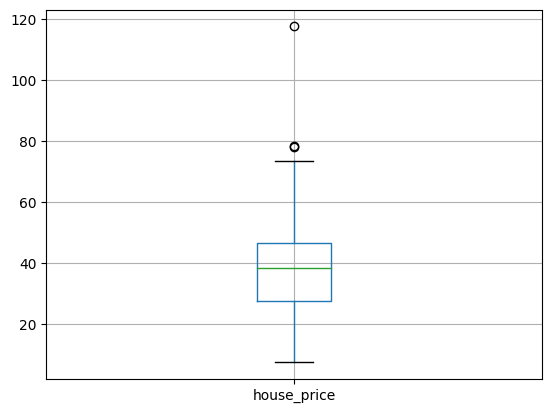

In [ ]:
df.boxplot(column = ['house_price'])

In [ ]:
Q1 = df.dist_to_MRT.quantile(0.25)
Q3 = df.dist_to_MRT.quantile(0.75)
IQR = Q3 - Q1
df_1 = df[~((df.dist_to_MRT < (Q1 - 1.5 * IQR)) | (df.dist_to_MRT > (Q3 +1.5 *IQR)))]
print(df.shape)
print(df_1.shape)

(414, 8)
(377, 8)


In [ ]:
Q1 = df_1.lat.quantile(0.25)
Q3 = df_1.lat.quantile(0.75)
IQR = Q3 - Q1
df_2 = df_1[~((df_1.lat < (Q1 - 1.5 * IQR)) | (df_1.lat > (Q3 +1.5 *IQR)))]
print(df_1.shape)
print(df_2.shape)

(377, 8)
(376, 8)


In [ ]:
Q1 = df_2.long.quantile(0.25)
Q3 = df_2.long.quantile(0.75)
IQR = Q3 - Q1
df_3 = df_2[~((df_2.long < (Q1 - 1.5 * IQR)) | (df_2.long > (Q3 +1.5 *IQR)))]
print(df_2.shape)
print(df_3.shape)

(376, 8)
(315, 8)


In [ ]:
Q1 = df_3.house_price.quantile(0.25)
Q3 = df_3.house_price.quantile(0.75)
IQR = Q3 - Q1
df_4 = df_3[~((df_3.house_price < (Q1 - 1.5 * IQR)) | (df_3.house_price > (Q3 +1.5 *IQR)))]
print(df_3.shape)
print(df_4.shape)

(315, 8)
(303, 8)


In [ ]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df_5 = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 +1.5 *IQR))).any(axis=1)]
print(df.shape)
print(df_5.shape)

(414, 8)
(371, 8)


In [ ]:
df_5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 371 entries, 0 to 413
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   No                371 non-null    int64  
 1   transaction_date  371 non-null    int64  
 2   house_age         371 non-null    float64
 3   dist_to_MRT       371 non-null    float64
 4   conv_store        371 non-null    int64  
 5   lat               371 non-null    float64
 6   long              371 non-null    float64
 7   house_price       371 non-null    float64
dtypes: float64(5), int64(3)
memory usage: 26.1 KB


/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


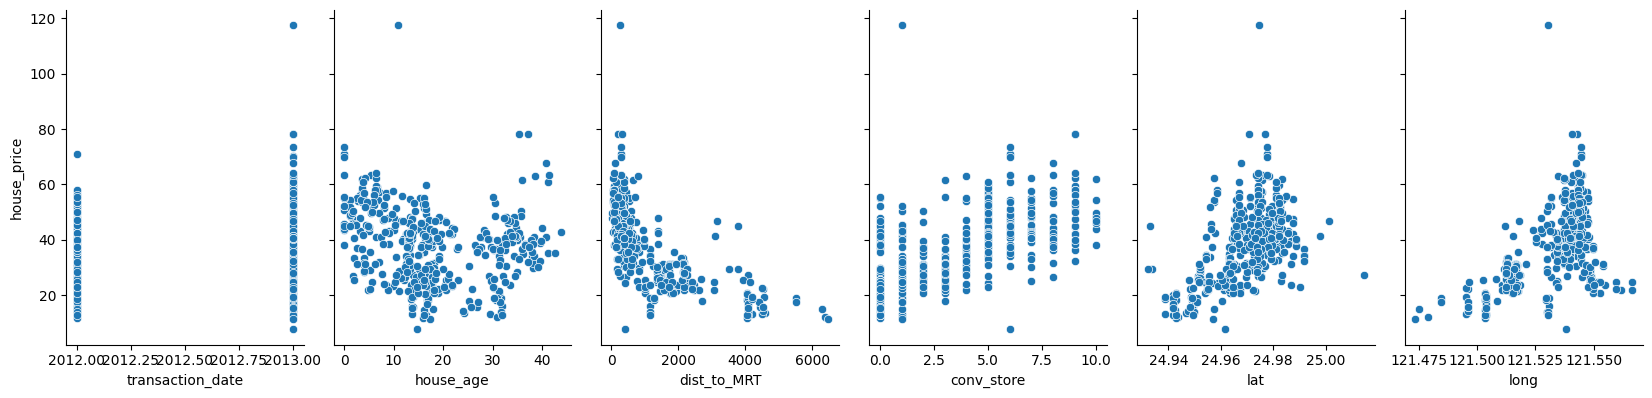

In [ ]:
#menggunakan scatterplots untuk cek hubungan liniear antara house price dengan kolom lainnya
p = sns.pairplot(df, x_vars=['transaction_date', 'house_age', 'dist_to_MRT', 'conv_store', 'lat', 'long'], y_vars= 'house_price', height=4, aspect=0.7)

/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


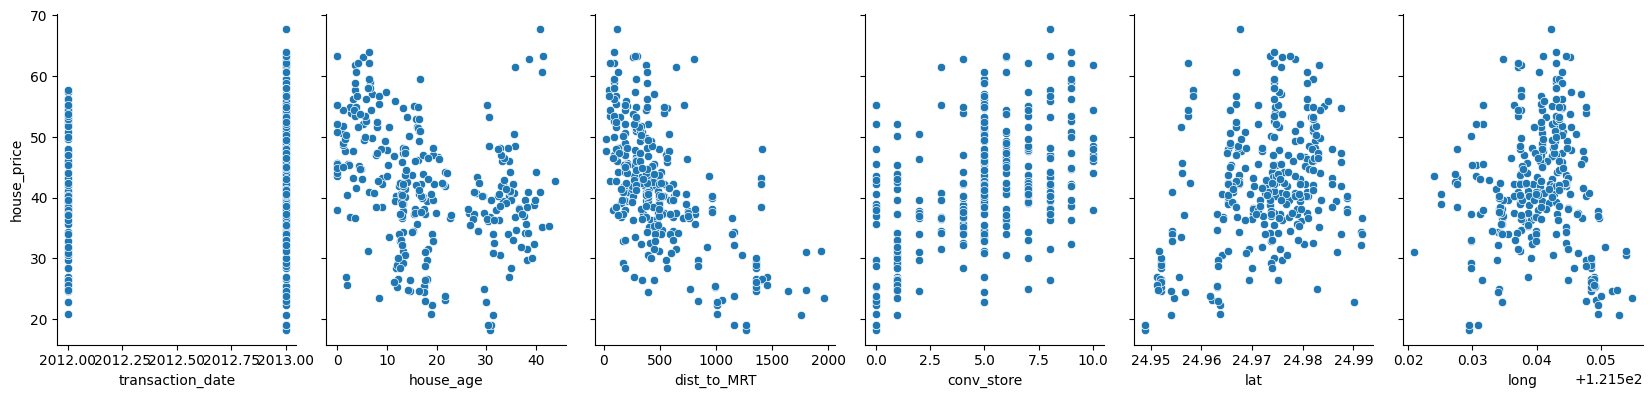

In [ ]:
#cek data setelah dikeluarkan outliernya
p = sns.pairplot(df_4, x_vars=['transaction_date', 'house_age', 'dist_to_MRT', 'conv_store', 'lat', 'long'], y_vars= 'house_price', height=4, aspect=0.7)

/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


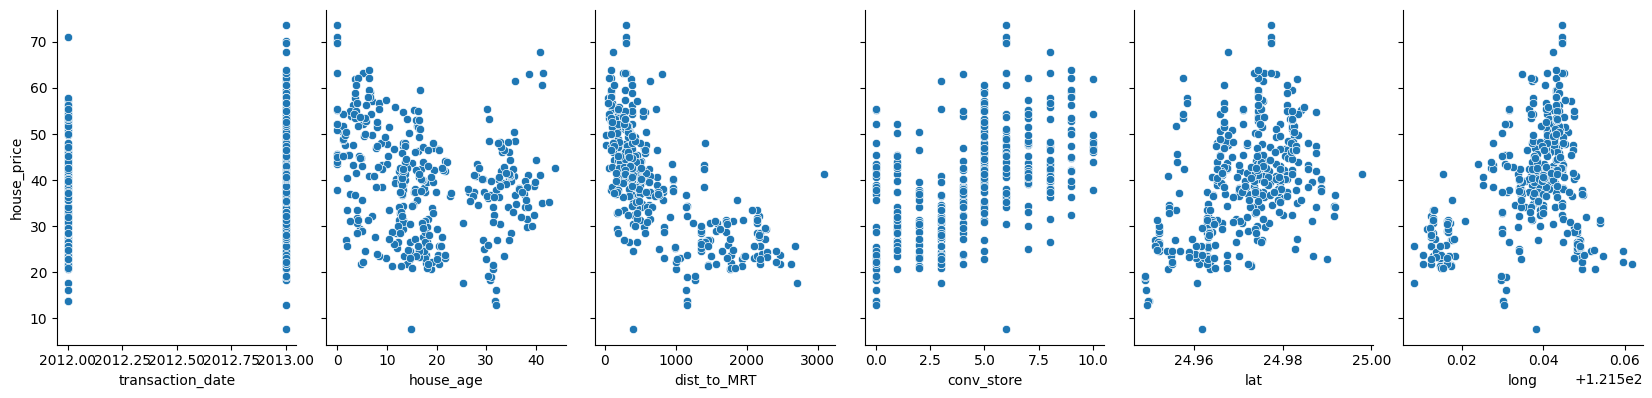

In [ ]:
p = sns.pairplot(df_5, x_vars=['transaction_date', 'house_age', 'dist_to_MRT', 'conv_store', 'lat', 'long'], y_vars= 'house_price', height=4, aspect=0.7)

In [ ]:
df_model_house_age_l_20 = df[df['house_age'] < 20]
df_model_house_age_m_20 = df[df['house_age'] > 20]

/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


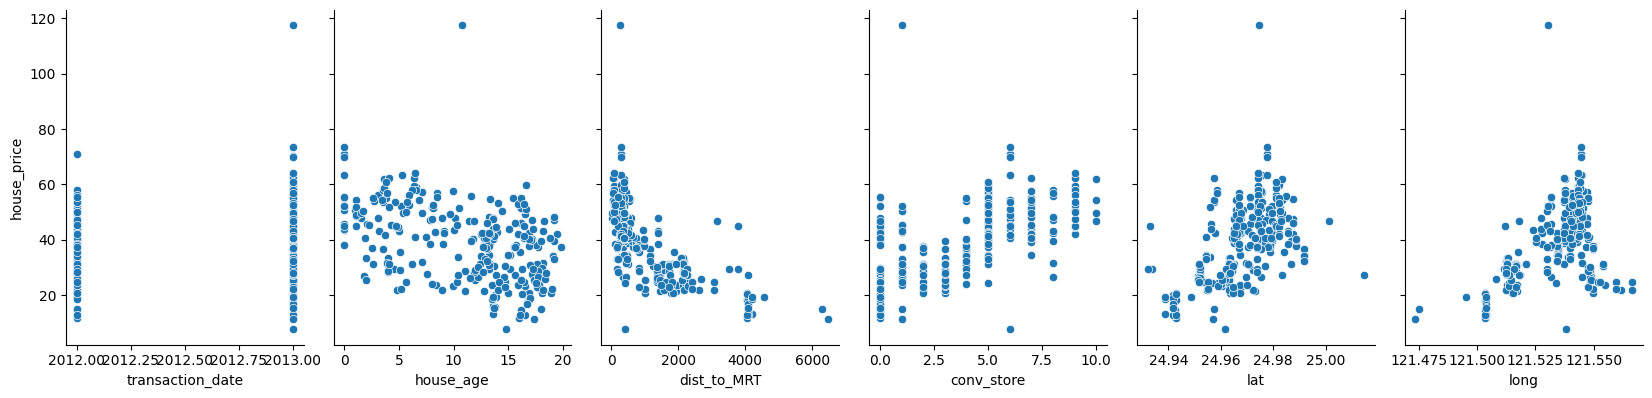

In [ ]:
p = sns.pairplot(df_model_house_age_l_20, x_vars=['transaction_date', 'house_age', 'dist_to_MRT', 'conv_store', 'lat', 'long'], y_vars= 'house_price', height=4, aspect=0.7)

/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


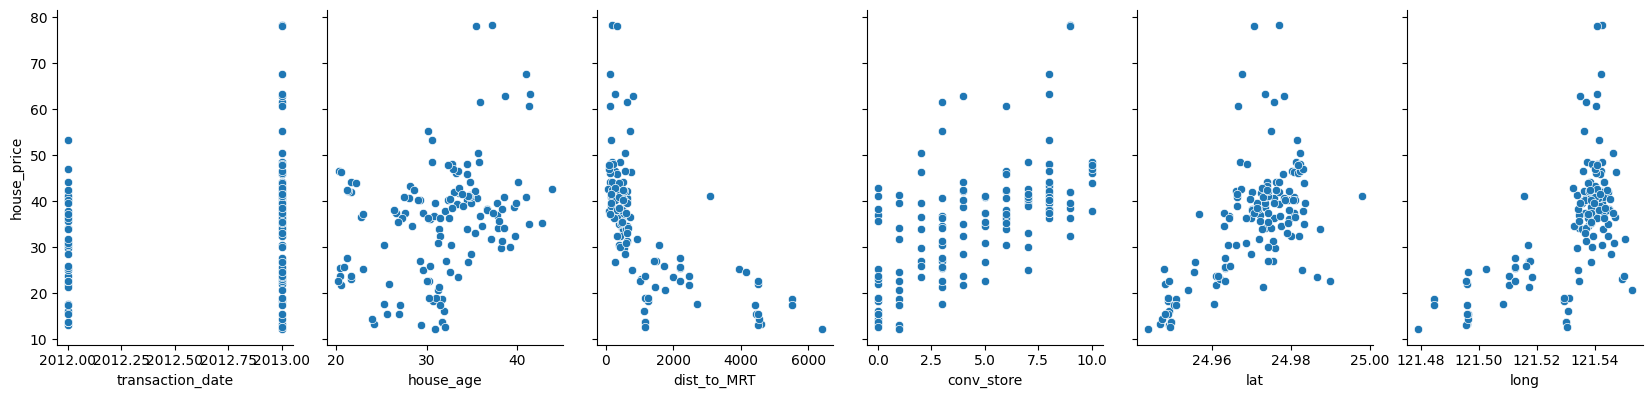

In [ ]:
p = sns.pairplot(df_model_house_age_m_20, x_vars=['transaction_date', 'house_age', 'dist_to_MRT', 'conv_store', 'lat', 'long'], y_vars= 'house_price', height=4, aspect=0.7)

<Axes: >

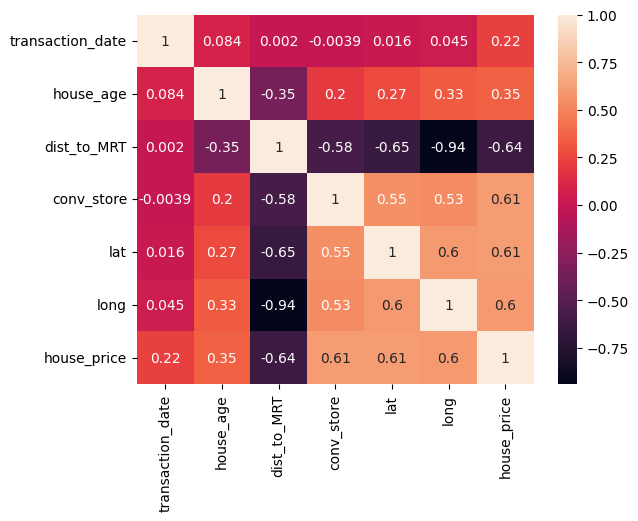

In [ ]:
sns.heatmap(df_model_house_age_m_20.drop(columns=['No']).corr(), annot=True)

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop(['house_price'],axis=1)
y = df.house_price
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2,random_state = 0)

In [ ]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_train, y_train)

LinearRegression()

In [ ]:
reg.coef_

array([-5.30413265e-03,  2.68096447e+00, -2.66453987e-01, -4.40560439e-03,
        1.11189597e+00,  2.33291255e+02, -1.39919126e+01])

In [ ]:
y_pred = reg.predict(X_test)
y_pred

array([38.98583161, 13.104198  , 41.74054363, 12.06317213, 40.91304714,
       40.23775488, 41.00955577, 35.90941863, 49.80659265, 44.9922497 ,
       45.50474025, 42.4516471 , 38.14279633, 41.09032116, 46.07379506,
       37.37687329, 40.38034933, 41.01129854, 41.09404069, 41.71922144,
       49.56787771, 32.424555  , 38.41063178, 47.47261579, 45.78450396,
       42.23371425, 45.80987366, 26.54279937, 47.57416869, 20.42347795,
       42.8460876 , 33.56409693, 43.00413941, 37.89257859, 42.88023863,
       30.68985415, 47.8967069 , 40.19216462, 52.73414137,  7.51269689,
       51.22572211, 33.00475213, 33.41570795, 47.85450594, 14.86139178,
       43.82643854, 42.5369668 , 12.28884439, 34.34518906, 46.82947542,
       51.65908557, 40.36405957, 48.199612  , 24.92946369, 31.88365821,
       33.32607904, 48.45566043, 41.68045411, 43.35999212, 33.56459588,
       43.02618827, 43.76211504, 40.83283534, 46.73917491, 37.60934539,
       30.96462021, 11.25570729, 34.46751544, 47.7062734 , 41.72

In [ ]:
from sklearn.metrics import r2_score
print('r2 Score : ', r2_score(y_test, y_pred))

r2 Score :  0.6589431008263702


In [ ]:
df_4.columns

Index(['No', 'transaction_date', 'house_age', 'dist_to_MRT', 'conv_store',
       'lat', 'long', 'house_price'],
      dtype='object')

In [ ]:
df_4['trans_dist_to_mrt'] = np.log(df_4.dist_to_MRT.copy())

/tmp/ipykernel_32/1054486219.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_4['trans_dist_to_mrt'] = np.log(df_4.dist_to_MRT.copy())


In [ ]:
X_1 = df_4.drop(['No', 'transaction date', 'lat', 'long', 'trans_dist_to_mrt', 'house_price'],axis=1)
X_1
X_2 = df_4.drop(['No', 'transaction date', 'lat', 'long', 'dist_to_mrt', 'house_price'],axis=1)